In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [2]:
from data_parser import clean_df
import pandas as pd
import matplotlib.pyplot as plt
df=clean_df(pd.read_csv("./data/prices.csv"))

In [3]:
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,0,0,5013,5,5014,15,0,0,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,0,0,10008,14,10010,29,0,0,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,0,0,10008,11,10010,22,0,0,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,0,0,5013,8,5014,21,0,0,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,0,0,10008,15,10010,20,0,0,10000.0,0.0


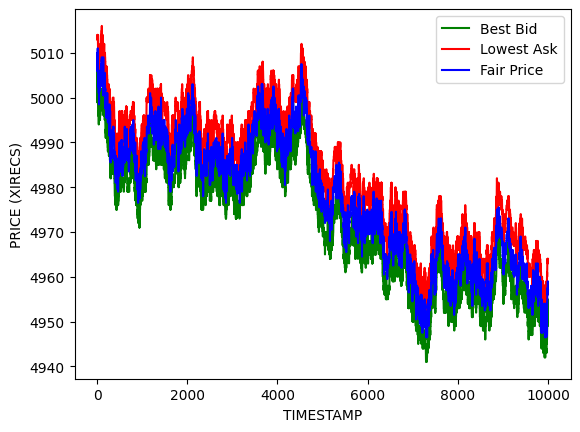

In [4]:
#TOMATOES RESEARCH

tomatoes_bid_price = df.loc[df['product']=="TOMATOES"]["bid_price_1"].to_numpy()
tomatoes_ask_price = df.loc[df['product']=="TOMATOES"]["ask_price_1"].to_numpy()
tomatoes_mid_price = df.loc[df['product']=="TOMATOES"]["mid_price"].to_numpy().astype(float)

plt.plot([i for i in range(len(tomatoes_bid_price))], tomatoes_bid_price, color="green", label="Best Bid")
plt.plot([i for i in range(len(tomatoes_bid_price))], tomatoes_ask_price, color="red", label="Lowest Ask")
plt.plot([i for i in range(len(tomatoes_bid_price))], tomatoes_mid_price, color="blue", label="Fair Price")
plt.legend()
plt.xlabel("TIMESTAMP")
plt.ylabel("PRICE (XIRECS)")
plt.show()

In [ ]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List




class UserTrader(Trader):
    def __init__(self):
        self.alpha = 0.2 # EMA SMOOTH

    def update_ema(self, product, price):
        if product not in self.ema:
            self.ema[product] = price
        else:
            self.ema[product] = self.alpha * price + (1 - self.alpha) * self.ema[product]

    def update_vol(self, product, price):
        if product not in self.vol:
            self.vol[product] = 1
        else:
            self.vol[product] = 0.8 * self.vol[product] + 0.2 * abs(price - self.ema[product])

    def trade_elemeralds(self, state: TradingState):
        LIMIT = 40
        position = state.position.get("EMERALDS", 0)
        if position >= LIMIT: # flatten position to 0
           self.result["EMERALDS"].append(Order("EMERALDS", 10000, -state.position["EMERALDS"]))
           return
        elif position <= -LIMIT: # flatten position to 0
           self.result["EMERALDS"].append(Order("EMERALDS", 10000, abs(state.position["EMERALDS"])))
           return 
        
        best_bid = max(state.order_depths["EMERALDS"].buy_orders)
        best_ask = min(state.order_depths["EMERALDS"].sell_orders)

        bid_quote = best_bid + 1
        ask_quote = best_ask - 1

        if bid_quote < 10000:
            self.result["EMERALDS"].append(Order("EMERALDS", bid_quote, min(LIMIT-position,(int((10000-bid_quote)/8 * 10)))))
        if ask_quote > 10000:
            self.result["EMERALDS"].append(Order("EMERALDS", ask_quote, max(-LIMIT-position,-(int((ask_quote-10000)/8 * 10)))))
        

    def trade_tomatoes(self, state: TradingState):
        LIMIT = 50
        position = state.position.get("TOMATOES", 0)
        spread = 1 + self.j_data["TOMATOES_MV"] * 0.3
        skew = position * 0.3
        fair = self.j_data["TOMATOES_EMA"]
        # gen quotes
        buy_price = int(fair - spread - skew)
        sell_price = int(fair + spread - skew)

        # Submitting orders
        if position < LIMIT:
            buy_qty = min(10, LIMIT - position)
            self.result["TOMATOES"].append(Order("TOMATOES", buy_price, buy_qty))

        if position > -LIMIT:
            sell_qty = min(10, LIMIT + position)
            self.result["TOMATOES"].append(Order("TOMATOES", sell_price, -sell_qty))


    def run(self, state: TradingState):
        # Reset result state
        self.result={}
        if state.traderData != "":
            self.j_data = json.loads(state.traderData)

            # Update Data
            mp = (max(state.order_depths["TOMATOES"].buy_orders) + min(state.order_depths["TOMATOES"].sell_orders)) / 2
            self.j_data["TOMATOES_EMA"] = self.alpha * mp + (1 - self.alpha) * self.j_data["TOMATOES_EMA"]
            self.j_data["TOMATOES_MV"] = 0.8 * self.j_data["TOMATOES_MV"] + 0.2 * abs(mp - self.j_data["TOMATOES_EMA"])
            
        else:
            self.j_data = {
                "TOMATOES_EMA": (max(state.order_depths["TOMATOES"].buy_orders) + min(state.order_depths["TOMATOES"].sell_orders)) / 2,
                "TOMATOES_MV": 1
            }
        self.result["EMERALDS"]=[]
        self.result["TOMATOES"]=[]
        
        # Call Trading Functions
        self.trade_elemeralds(state)
        self.trade_tomatoes(state)

        return self.result, 0, json.dumps(self.j_data)

In [6]:
backtesting_engine = Backtester("./data/prices2.csv", "./data/trades.csv")

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [19]:
sample_trader = UserTrader()
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)

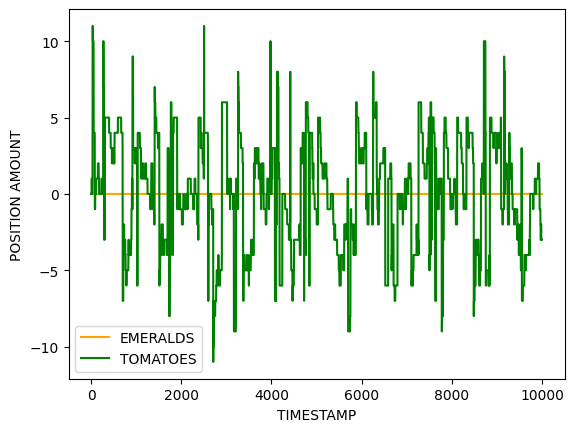

In [20]:
backtesting_result.graph_inventory()

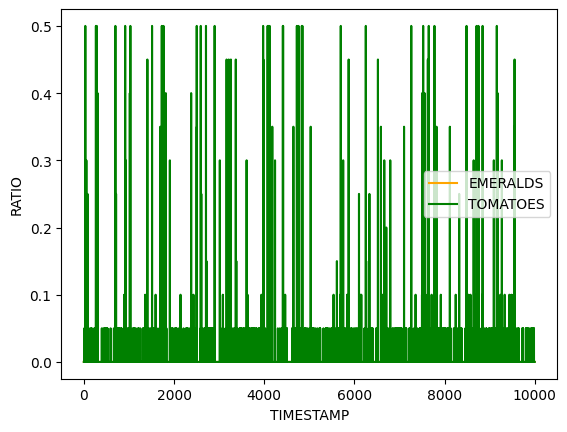

In [21]:
backtesting_result.graph_fill_ratios()

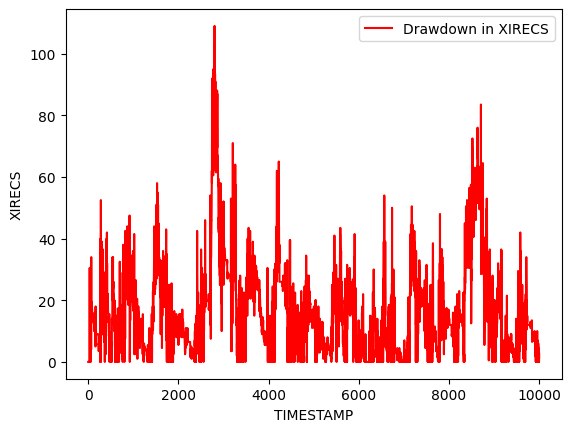

In [22]:
backtesting_result.graph_drawdown()

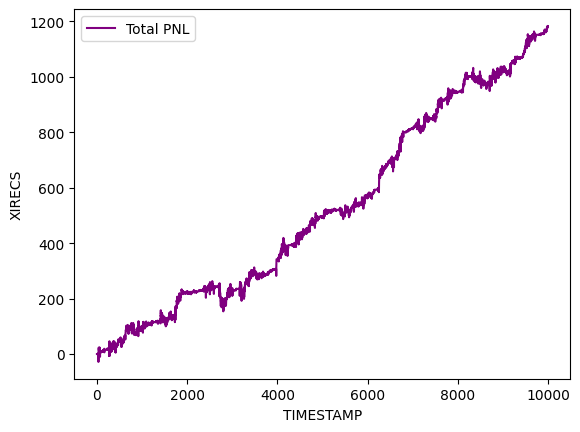

In [23]:
backtesting_result.graph_pnl()

In [26]:
import math

total_runs = 100
all_end_pnl=[]
all_sharpe=[]
for i in range(total_runs):
    backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)
    t_sum = 0
    total_pnl_series=[]
    for symbol in backtesting_engine.symbols:
        t_sum+=backtesting_result.pnl_realized[len(backtesting_result.pnl_realized)-1][symbol]
        t_sum+=backtesting_result.pnl_unrealized[len(backtesting_result.pnl_realized)-1][symbol]

    for t in range(len(backtesting_result.pnl_realized)):
        s=0
        for symbol in backtesting_engine.symbols:
            s+=backtesting_result.pnl_realized[t][symbol]
            s+=backtesting_result.pnl_unrealized[t][symbol]
        total_pnl_series.append(s)

    returns = np.diff(total_pnl_series)
    mean_ret = returns.mean()
    std_ret = returns.std()
    all_sharpe.append((mean_ret/std_ret)*math.sqrt(len(backtesting_result.pnl_realized)))
    all_end_pnl.append(t_sum)



(array([ 2.,  2.,  6., 17., 17., 20., 19.,  9.,  6.,  2.]),
 array([12799.5 , 12907.15, 13014.8 , 13122.45, 13230.1 , 13337.75,
        13445.4 , 13553.05, 13660.7 , 13768.35, 13876.  ]),
 <BarContainer object of 10 artists>)

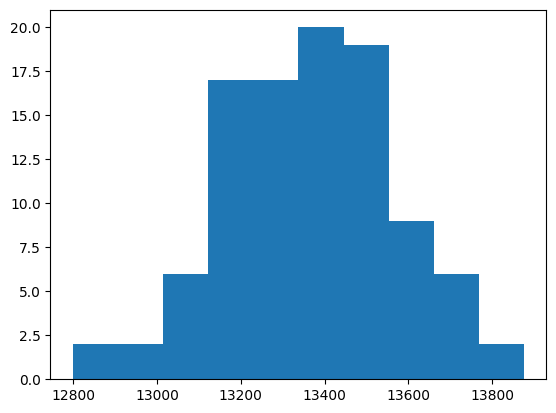

In [29]:
#plt.hist(all_sharpe, bins=10)
plt.hist(all_end_pnl, bins=10)

In [64]:
backtesting_engine.get_fill_probability(1)

0.04742587317756678

(array([ 2.,  6., 19., 19., 19., 13.,  7.,  9.,  4.,  2.]),
 array([ 515.  ,  581.75,  648.5 ,  715.25,  782.  ,  848.75,  915.5 ,
         982.25, 1049.  , 1115.75, 1182.5 ]),
 <BarContainer object of 10 artists>)

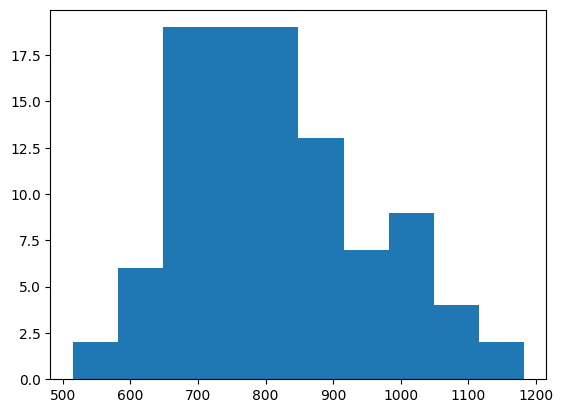

In [ ]:
plt.hist(all_end_pnl)

In [ ]:
plt.plot([i for i in range(len(total_pnl))], inventory, color="green")

NameError: name 'total_pnl' is not defined

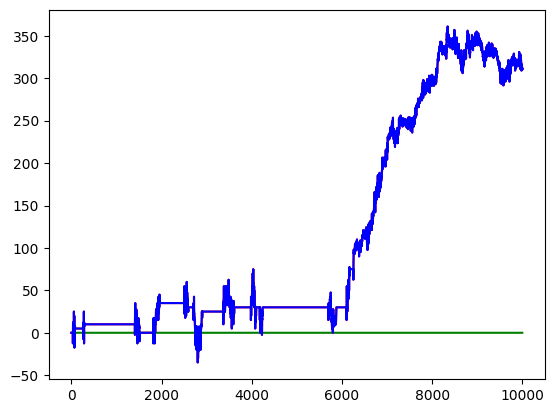

In [ ]:


plt.plot([i for i in range(len(total_pnl))], total_pnl, color="blue")